<p style="font-family: Arial; font-size:2.75em;color:purple; font-style:bold"><br>

Clustering com scikit-learn

<br><br></p>

Neste notebook, vamos aprender como realizar agrupamento k-means usando o scikit-learn em Python.

Usaremos a análise de clusters para gerar um modelo geral do clima em uma estação local, utilizando dados com granularidade de um minuto. Neste conjunto de dados, temos na ordem de milhões de registros. Como podemos criar 12 clusters a partir deles?

<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Fazendo imports necessários<br></p>

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
from itertools import cycle, islice
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

%matplotlib inline

Criando um DataFrame com Pandas.

In [24]:
data = pd.read_csv(r'C:\Users\mathe\Downloads\Week-7-MachineLearning (1)\Week-7-MachineLearning\weather\minute_weather.csv')

<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold">Descrição dos Dados de Clima por Minuto</p> 
<br> 
O **conjunto de dados de clima por minuto** vem da mesma fonte do conjunto de dados de clima diário que usamos no notebook de classificador baseado em árvore de decisão. A principal diferença entre esses dois conjuntos de dados é que o conjunto de dados de clima por minuto contém **medições brutas dos sensores**, capturadas em intervalos de **um minuto**. Já o conjunto de dados de clima diário contém dados **processados e bem organizados**. Os dados estão no arquivo **minute_weather.csv**, que é um arquivo separado por vírgulas (CSV).
Assim como os dados diários, este conjunto vem de uma estação meteorológica localizada em San Diego, Califórnia. A estação está equipada com sensores que capturam medições relacionadas ao clima, como temperatura do ar, pressão atmosférica e umidade relativa. Os dados foram coletados por um período de três anos, de setembro de 2011 a setembro de 2014, para garantir a coleta de informações suficientes sobre diferentes estações e condições climáticas.

Cada linha do arquivo minute_weather.csv contém os dados meteorológicos capturados para um intervalo de um minuto. Cada linha, ou amostra, consiste nas seguintes variáveis:

rowID: número único para cada linha (Unidade: N/A)

hpwren_timestamp: data e hora da medição (Unidade: ano-mês-dia hora:minuto:segundo)

air_pressure: pressão atmosférica medida no momento (Unidade: hectopascais)

air_temp: temperatura do ar medida no momento (Unidade: graus Fahrenheit)

avg_wind_direction: direção média do vento no minuto anterior (Unidade: graus, sendo 0 vindo do Norte, aumentando no sentido horário)

avg_wind_speed: velocidade média do vento no minuto anterior (Unidade: metros por segundo)

max_wind_direction: maior direção do vento no minuto anterior (Unidade: graus, com 0 sendo Norte e aumentando no sentido horário)

max_wind_speed: maior velocidade do vento no minuto anterior (Unidade: metros por segundo)

min_wind_direction: menor direção do vento no minuto anterior (Unidade: graus, com 0 sendo Norte e aumentando no sentido horário)

min_wind_speed: menor velocidade do vento no minuto anterior (Unidade: metros por segundo)

rain_accumulation: quantidade de chuva acumulada medida no momento (Unidade: milímetros)

rain_duration: tempo de duração da chuva medido no momento (Unidade: segundos)

relative_humidity: umidade relativa medida no momento (Unidade: porcentagem)


In [25]:
data.shape

(1587257, 13)

In [26]:
data.head()

,rowID,hpwren_timestamp,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,min_wind_direction,min_wind_speed,rain_accumulation,rain_duration,relative_humidity
0,0,2011-09-10 00:00:49,912.3,64.76,97.0,1.2,106.0,1.6,85.0,1.0,NaN,NaN,60.5
1,1,2011-09-10 00:01:49,912.3,63.86,161.0,0.8,215.0,1.5,43.0,0.2,0.0,0.0,39.9
2,2,2011-09-10 00:02:49,912.3,64.22,77.0,0.7,143.0,1.2,324.0,0.3,0.0,0.0,43.0
3,3,2011-09-10 00:03:49,912.3,64.40,89.0,1.2,112.0,1.6,12.0,0.7,0.0,0.0,49.5
4,4,2011-09-10 00:04:49,912.3,64.40,185.0,0.4,260.0,1.0,100.0,0.1,0.0,0.0,58.8


<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Amostragem de dados<br></p>

Muitas linhas, então vamos amostrar para baixo, tomando cada 10ª linha. <br>

In [27]:
sample_df = data[(data['rowID'] % 10 ) == 0] # Pega o valor da coluna rowID e calcula o resto da divisão por 10. Seleciona apenas as linhas  cujo rowID é divisivel por 10
sample_df.shape # Mostra quantidade de linhas e colunas

(158726, 13)

<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Estatísticas
<br><br></p>

In [28]:
sample_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
rowID,158726.0,793625.000000,458203.937509,0.00,396812.5,793625.00,1190437.50,1587250.00
air_pressure,158726.0,916.830161,3.051717,905.00,914.8,916.70,918.70,929.50
air_temp,158726.0,61.851589,11.833569,31.64,52.7,62.24,70.88,99.50
avg_wind_direction,158680.0,162.156100,95.278201,0.00,62.0,182.00,217.00,359.00
avg_wind_speed,158680.0,2.775215,2.057624,0.00,1.3,2.20,3.80,31.90
max_wind_direction,158680.0,163.462144,92.452139,0.00,68.0,187.00,223.00,359.00
max_wind_speed,158680.0,3.400558,2.418802,0.10,1.6,2.70,4.60,36.00
min_wind_direction,158680.0,166.774017,97.441109,0.00,76.0,180.00,212.00,359.00
min_wind_speed,158680.0,2.134664,1.742113,0.00,0.8,1.60,3.00,31.60
rain_accumulation,158725.0,0.000318,0.011236,0.00,0.0,0.00,0.00,3.12


In [29]:
sample_df[sample_df['rain_accumulation'] == 0 ].shape # Acessando valores da coluna 'rain_accumulation' onde valores são iguais a 0

(157812, 13)

In [30]:
sample_df[sample_df['rain_duration']== 0].shape # Acessando valores da coluna 'rain_duration' onde valores são iguais a 0

(157237, 13)

<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Eliminando todas as linhas com valores vazios em rain_duration e em rain_accumulation
<br><br></p>


In [31]:
del sample_df['rain_accumulation']
del sample_df['rain_duration']

In [34]:
rows_before = sample_df.shape[0]
sample_df = sample_df.dropna()
rows_after = sample_df.shape[0]

<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Quantas linhas nós tiramos ?
<br><br></p>


In [ ]:
rows_before - rows_after # 46

46

In [36]:
sample_df.columns

Index(['rowID', 'hpwren_timestamp', 'air_pressure', 'air_temp',
       'avg_wind_direction', 'avg_wind_speed', 'max_wind_direction',
       'max_wind_speed', 'min_wind_direction', 'min_wind_speed',
       'relative_humidity'],
      dtype='object')

<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Selecionando recursos importnates para o clustering
<br><br></p>


In [ ]:
features = ['air_pressure', 'air_temp', 'avg_wind_direction', 'avg_wind_speed', 'max_wind_direction', 
        'max_wind_speed','relative_humidity'] # Criando máscara.

In [ ]:
select_df = sample_df[features] # Aplicando máscara 

In [39]:
select_df.columns

Index(['air_pressure', 'air_temp', 'avg_wind_direction', 'avg_wind_speed',
       'max_wind_direction', 'max_wind_speed', 'relative_humidity'],
      dtype='object')

In [40]:
select_df

,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,relative_humidity
0,912.3,64.76,97.0,1.2,106.0,1.6,60.5
10,912.3,62.24,144.0,1.2,167.0,1.8,38.5
20,912.2,63.32,100.0,2.0,122.0,2.5,58.3
30,912.2,62.60,91.0,2.0,103.0,2.4,57.9
40,912.2,64.04,81.0,2.6,88.0,2.9,57.4
...,...,...,...,...,...,...,...
1587210,915.9,75.56,330.0,1.0,341.0,1.3,47.8
1587220,915.9,75.56,330.0,1.1,341.0,1.4,48.0
1587230,915.9,75.56,344.0,1.4,352.0,1.7,48.0
1587240,915.9,75.20,359.0,1.3,9.0,1.6,46.3


<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Escalando recursos utilizando StandartScaler
<br><br></p>


In [ ]:
x = StandardScaler().fit_transform(select_df) # Deixando todas as variáveis na mesma escala
x

array([[-1.48456281,  0.24544455, -0.68385323, ..., -0.62153592,
        -0.74440309,  0.49233835],
       [-1.48456281,  0.03247142, -0.19055941, ...,  0.03826701,
        -0.66171726, -0.34710804],
       [-1.51733167,  0.12374562, -0.65236639, ..., -0.44847286,
        -0.37231683,  0.40839371],
       ...,
       [-0.30488381,  1.15818654,  1.90856325, ...,  2.0393087 ,
        -0.70306017,  0.01538018],
       [-0.30488381,  1.12776181,  2.06599745, ..., -1.67073075,
        -0.74440309, -0.04948614],
       [-0.30488381,  1.09733708, -1.63895404, ..., -1.55174989,
        -0.62037434, -0.05711747]])

<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Use K-Means para agrupar.
<br><br></p>

In [50]:
kmeans = KMeans(n_clusters=12) # Cria um objeto KMeans com 12 clusters 
model = kmeans.fit(x)# Aplica o algoritmo KMeans aos dados padronizados (x). Isso faz com que o modelo agrupe os dados em 12 grupos (clusters)
print("model\n", model) #Exibe o objeto do modelo treinado (mostra os parâmetros básicos do KMeans)

#print(model.labels_)
#print(kmeans.cluster_centers_)


model
 KMeans(n_clusters=12)


<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Quais são os centros dos 12 clusters que formamos?
<br><br></p>

In [51]:
centers = model.cluster_centers_
centers

array([[ 0.84771652,  0.19934388,  0.29853992, -0.58025021,  0.49488602,
        -0.58366262, -0.71372664],
       [-0.18638832, -1.08288679,  0.54324946, -0.26598206,  0.69459008,
        -0.26203629,  1.28371365],
       [-0.07485585,  0.80143275,  0.42643638,  0.51762334,  0.54183108,
         0.47319554, -0.23380102],
       [-1.30683001, -1.40921701,  0.37830946,  1.56396828,  0.48438603,
         1.55008683,  1.5104248 ],
       [-0.14935623,  0.85871858, -1.31054353, -0.58854978, -1.16609009,
        -0.60408293, -0.64590874],
       [ 0.13193236,  0.81293631,  1.41093073, -0.65349327,  1.67616219,
        -0.60568559, -0.6822523 ],
       [ 1.18318734, -0.26116024, -1.15304406,  2.1648822 , -1.05192359,
         2.28171038, -1.12597406],
       [-0.67061216,  0.56587595,  0.16520781, -0.62649239,  0.33909925,
        -0.63938809, -0.16089444],
       [-0.79267845, -0.1965197 ,  0.43844511,  1.5092303 ,  0.52345237,
         1.43888941,  0.27943194],
       [ 1.37177089, -0.0845

<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Plots
<br><br></p>

Vamos primeiro criar algumas funções utilitárias que nos ajudarão a traçar gráficos:

In [ ]:
# Function that creates a DataFrame with a column for Cluster Number

def pd_centers(featuresUsed, centers): # featuresUsed: Uma lista com os nomes das características usadas para o agrupamento / center: Centróides de cada cluster.
	colNames = list(featuresUsed) # Cria uma lista colnames a partir de featuresUsed
	colNames.append('prediction') # Depois, adiciona o nome 'prediction' ao final dessa lista

	Z = [np.append(A, index) for index, A in enumerate(centers)] #Aqui estamos combinando os valores de cada centróide com o índice do cluster ao qual ele pertence.

	# Converte para Pandas Dataframe para plotar 
	P = pd.DataFrame(Z, columns=colNames)
	P['prediction'] = P['prediction'].astype(int)
	return P

In [62]:
def parallel_plot(data):
	# A função cycle da biblioteca itertools cria um ciclo infinito de cores, Ou seja, ela vai repetir as cores da lista ['b', 'r', 'g', 'y', 'k'] (que são as cores azul, vermelho, verde, amarelo e preto) em loop, até que o número de cores seja suficiente para os dados.
	my_colors = list(islice(cycle(['b', 'r', 'g', 'y', 'k']), None, len(data)))
	plt.figure(figsize=(15,8)).gca().axes.set_ylim([-3,+3])
	parallel_coordinates(data, 'prediction', color = my_colors, marker='o')
	plt.show()

In [63]:
P = pd_centers(features, centers)
P

,air_pressure,air_temp,avg_wind_direction,avg_wind_speed,max_wind_direction,max_wind_speed,relative_humidity,prediction
0,0.847717,0.199344,0.298540,-0.580250,0.494886,-0.583663,-0.713727,0
1,-0.186388,-1.082887,0.543249,-0.265982,0.694590,-0.262036,1.283714,1
2,-0.074856,0.801433,0.426436,0.517623,0.541831,0.473196,-0.233801,2
3,-1.306830,-1.409217,0.378309,1.563968,0.484386,1.550087,1.510425,3
4,-0.149356,0.858719,-1.310544,-0.588550,-1.166090,-0.604083,-0.645909,4
5,0.131932,0.812936,1.410931,-0.653493,1.676162,-0.605686,-0.682252,5
6,1.183187,-0.261160,-1.153044,2.164882,-1.051924,2.281710,-1.125974,6
7,-0.670612,0.565876,0.165208,-0.626492,0.339099,-0.639388,-0.160894,7
8,-0.792678,-0.196520,0.438445,1.509230,0.523452,1.438889,0.279432,8
9,1.371771,-0.084558,-1.207382,-0.016200,-1.077219,0.006169,-0.981554,9


<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Dias secos
<br><br></p>

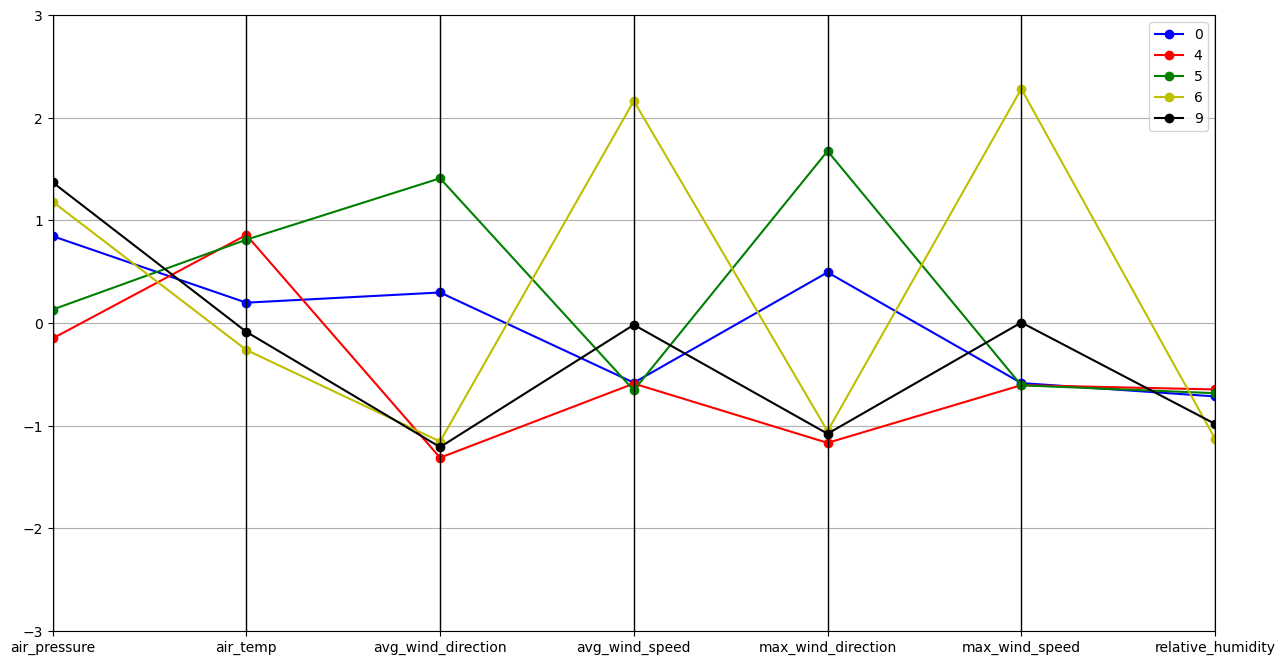

(5, 8)


In [ ]:
parallel_plot(P[P['relative_humidity'] < -0.5]) # Função Criada acima. 
#print(P[P['relative_humidity'] < -0.5].shape) 


<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Dias quentes
<br><br></p>

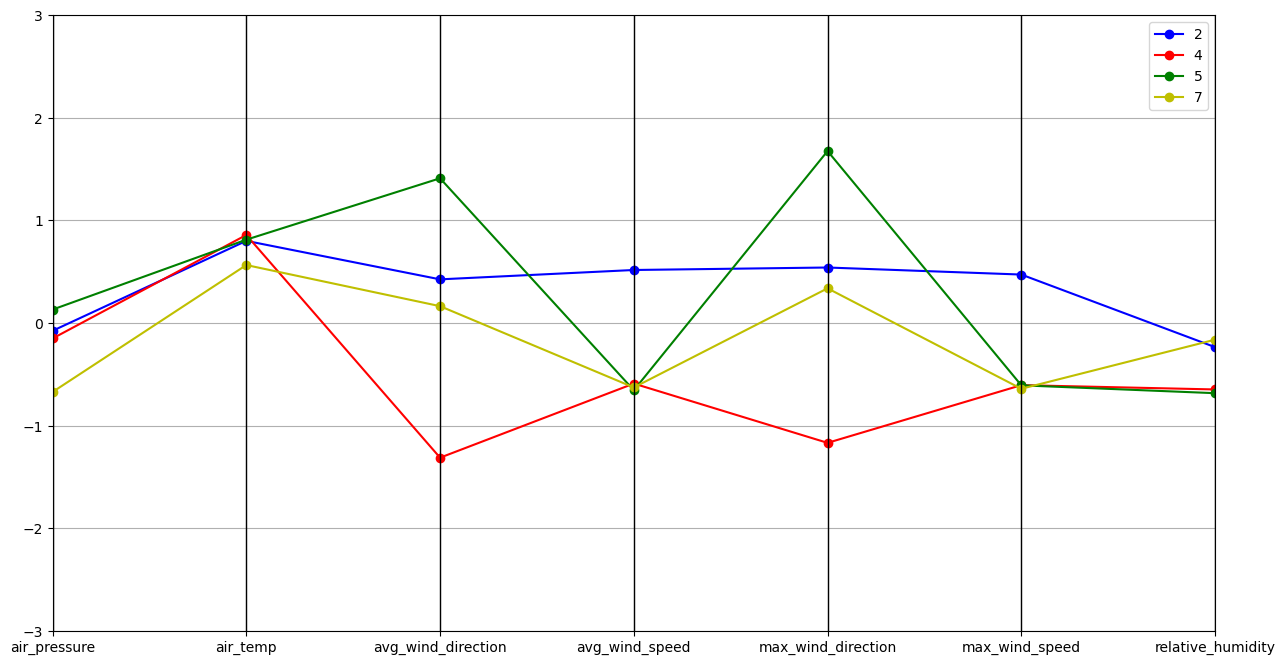

In [66]:
parallel_plot(P[P['air_temp'] > 0.5])

<p style="font-family: Arial; font-size:1.75em;color:purple; font-style:bold"><br>

Dias frios
<br><br></p>

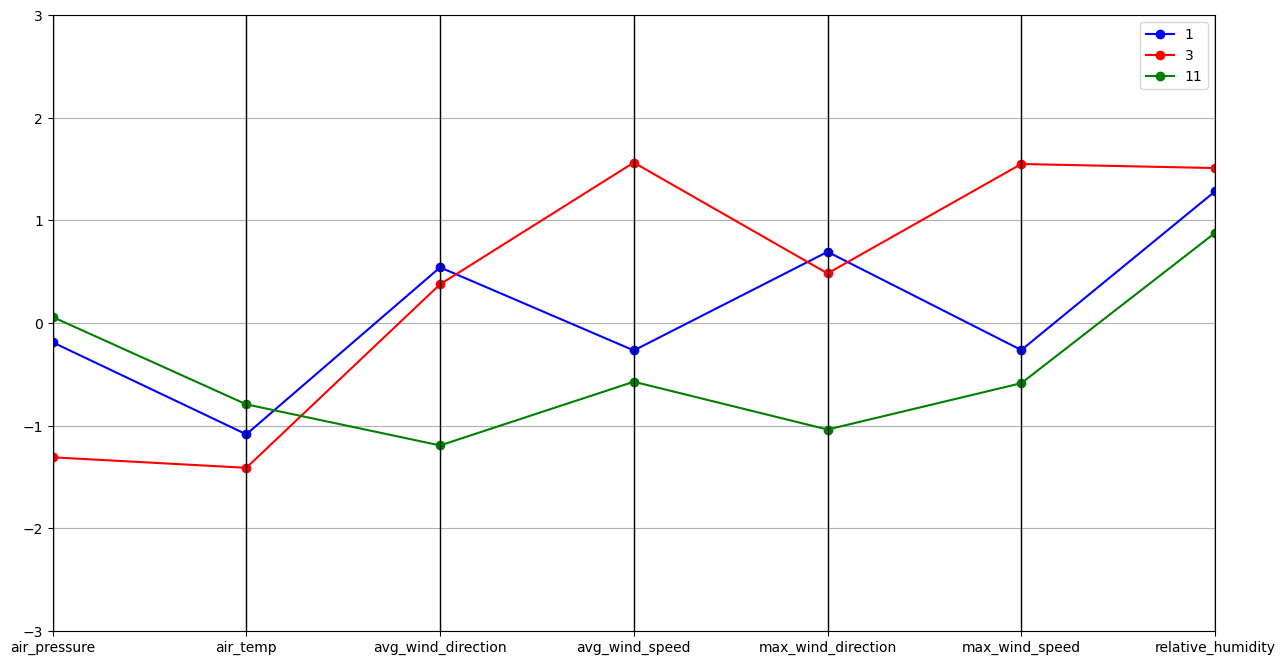

In [67]:
parallel_plot(P[(P['relative_humidity'] > 0.5) & (P['air_temp'] < 0.5)])